# Load & Explore Data

In [9]:
pip install pandas matplotlib seaborn scikit-learn


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 3.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.1 MB 3.8 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.1 MB 3.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.1 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 3.9 MB/s eta 0:00:02
   ----------------------- ---------------- 4.7/8.1 MB 3.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 3.8 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.1 MB 3.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 3.5 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 3.5 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 3.4 MB/s eta 0:00:00
   ----------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


(3276, 10)
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64
Potability
0    1998
1    1278
Name: count, dtype: int64


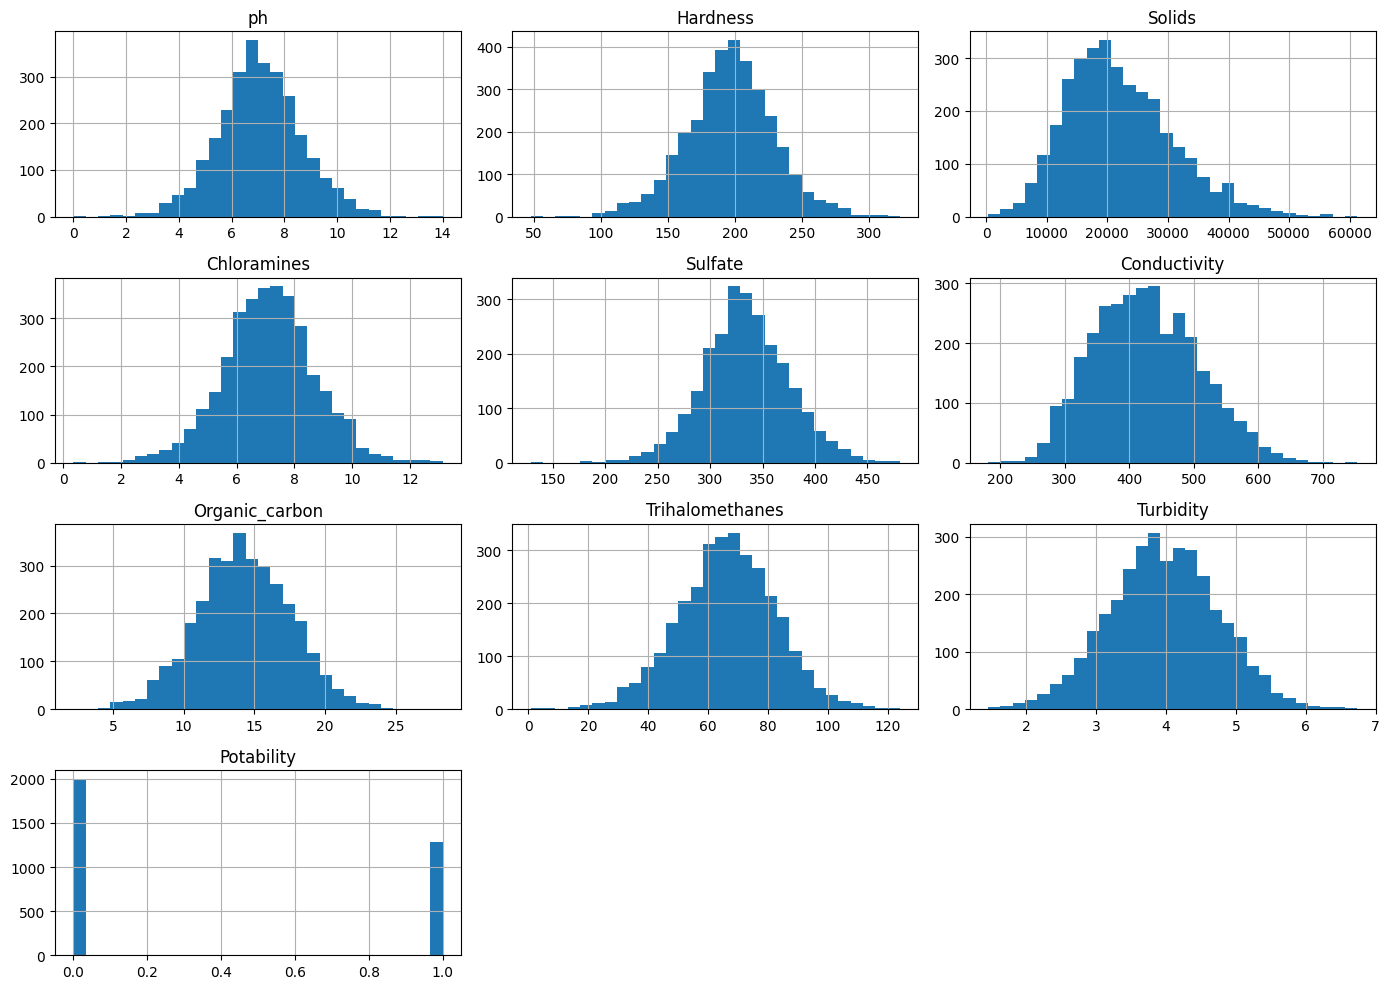

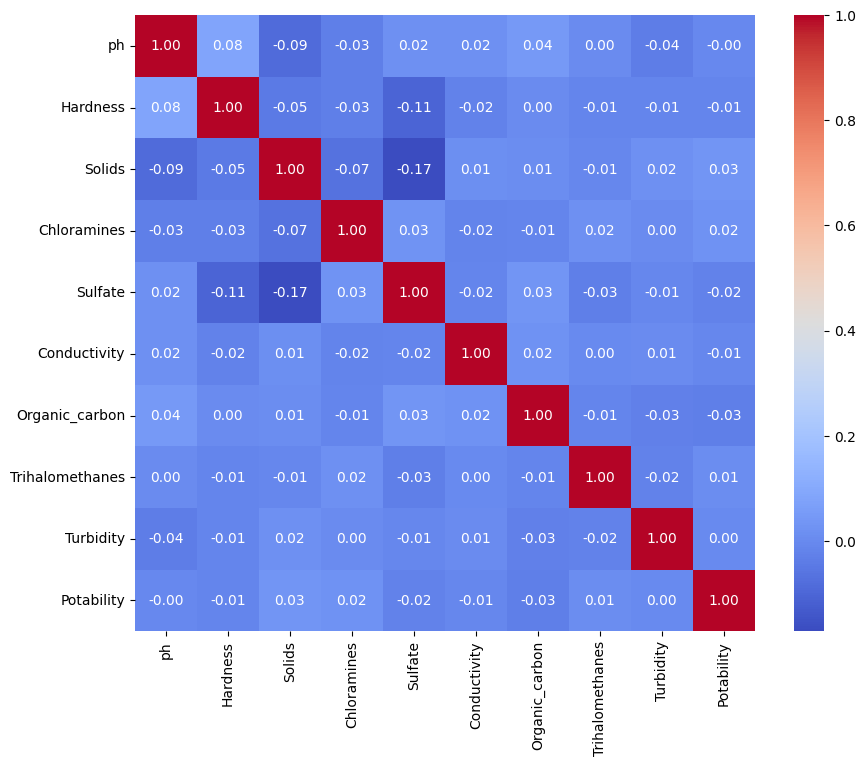

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("water_potability.csv")

print(df.shape)           # (3276, 10)
print(df.isnull().sum())  # pH, Sulfate, Trihalomethanes have nulls
print(df['Potability'].value_counts())  # class imbalance check

# Distribution plots
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout(); plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# Preprocessing + SMOTE
SMOTE - Synthetic Minority Oversampling Technique

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from imblearn.over_sampling import SMOTE

# Impute missing values
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

X = df_imputed.drop("Potability", axis=1)
y = df_imputed["Potability"]

# Scale
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE — fix class imbalance on training data only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", pd.Series(y_train_res).value_counts())

After SMOTE: Potability
0.0    1598
1.0    1598
Name: count, dtype: int64


Train and Evaluate Model

Import Libraries

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import time

# SHAP interpretability

In [14]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

feature_names = list(df.drop("Potability", axis=1).columns)

# Handle both old SHAP (list of arrays) and new SHAP (3D array)
if isinstance(shap_values, list):
    # Old SHAP: shap_values is [class_0_array, class_1_array]
    sv = shap_values[1]
else:
    # New SHAP: shap_values is shape (n_samples, n_features, n_classes)
    sv = shap_values[:, :, 1]

# Summary beeswarm plot
shap.summary_plot(sv, X_test, feature_names=feature_names)

# Bar chart of mean |SHAP|
shap.summary_plot(sv, X_test, feature_names=feature_names, plot_type="bar")

NameError: name 'best_rf' is not defined

# Save & Deploy

In [15]:
# save_model.py
import pickle
pickle.dump(best_rf, open("rf_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

NameError: name 'best_rf' is not defined